#Prediction Breast Cancer - Logistic Regression - Detailed One || Task Given: Day 8: Logistic Regression (23/06/2026) || Submited By: 24/06/2026
##Name: Manish Giri | Reg. No.:137256 | [LinkedIn]

#Task: We will build an example of Regression Analysis to clasify that predicts whether a tumor is malignant or benign, based on madeical measurements using python.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import neighbors
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             precision_score,
                             accuracy_score,
                             recall_score, f1_score,
                             roc_curve,roc_auc_score)
from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_csv('breast_cancer_Wisconsin(Diagnostic)_dataset.csv', index_col=0)
df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [4]:
#remove the Unnamed: 32 column
df = df.drop('Unnamed: 32', axis=1)

In [5]:
df.dtypes

diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [6]:
df.shape

(569, 31)

#EDA

C:\Users\Manish Giri\AppData\Local\Temp\ipykernel_9144\4153754487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='RdBu')


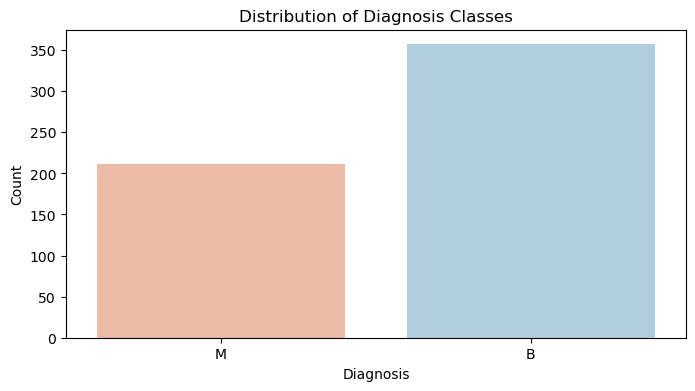

Number of cells labeled Benign: 357
Number of cells labeled Malignant: 212

Total % of cells labeled Benign: 62.74 %
Total % of cells labeled Malignant: 37.26 %


In [7]:
# Visualize distribution of classes
plt.figure(figsize=(8, 4))
sns.countplot(x='diagnosis', data=df, palette='RdBu')

plt.title('Distribution of Diagnosis Classes')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

# Count observations in each class
counts = df['diagnosis'].value_counts()

benign = counts.get('B', 0)      # Benign
malignant = counts.get('M', 0)   # Malignant

print('Number of cells labeled Benign:', benign)
print('Number of cells labeled Malignant:', malignant)
print()

print('Total % of cells labeled Benign:',
      round(benign / len(df) * 100, 2), '%')

print('Total % of cells labeled Malignant:',
      round(malignant / len(df) * 100, 2), '%')

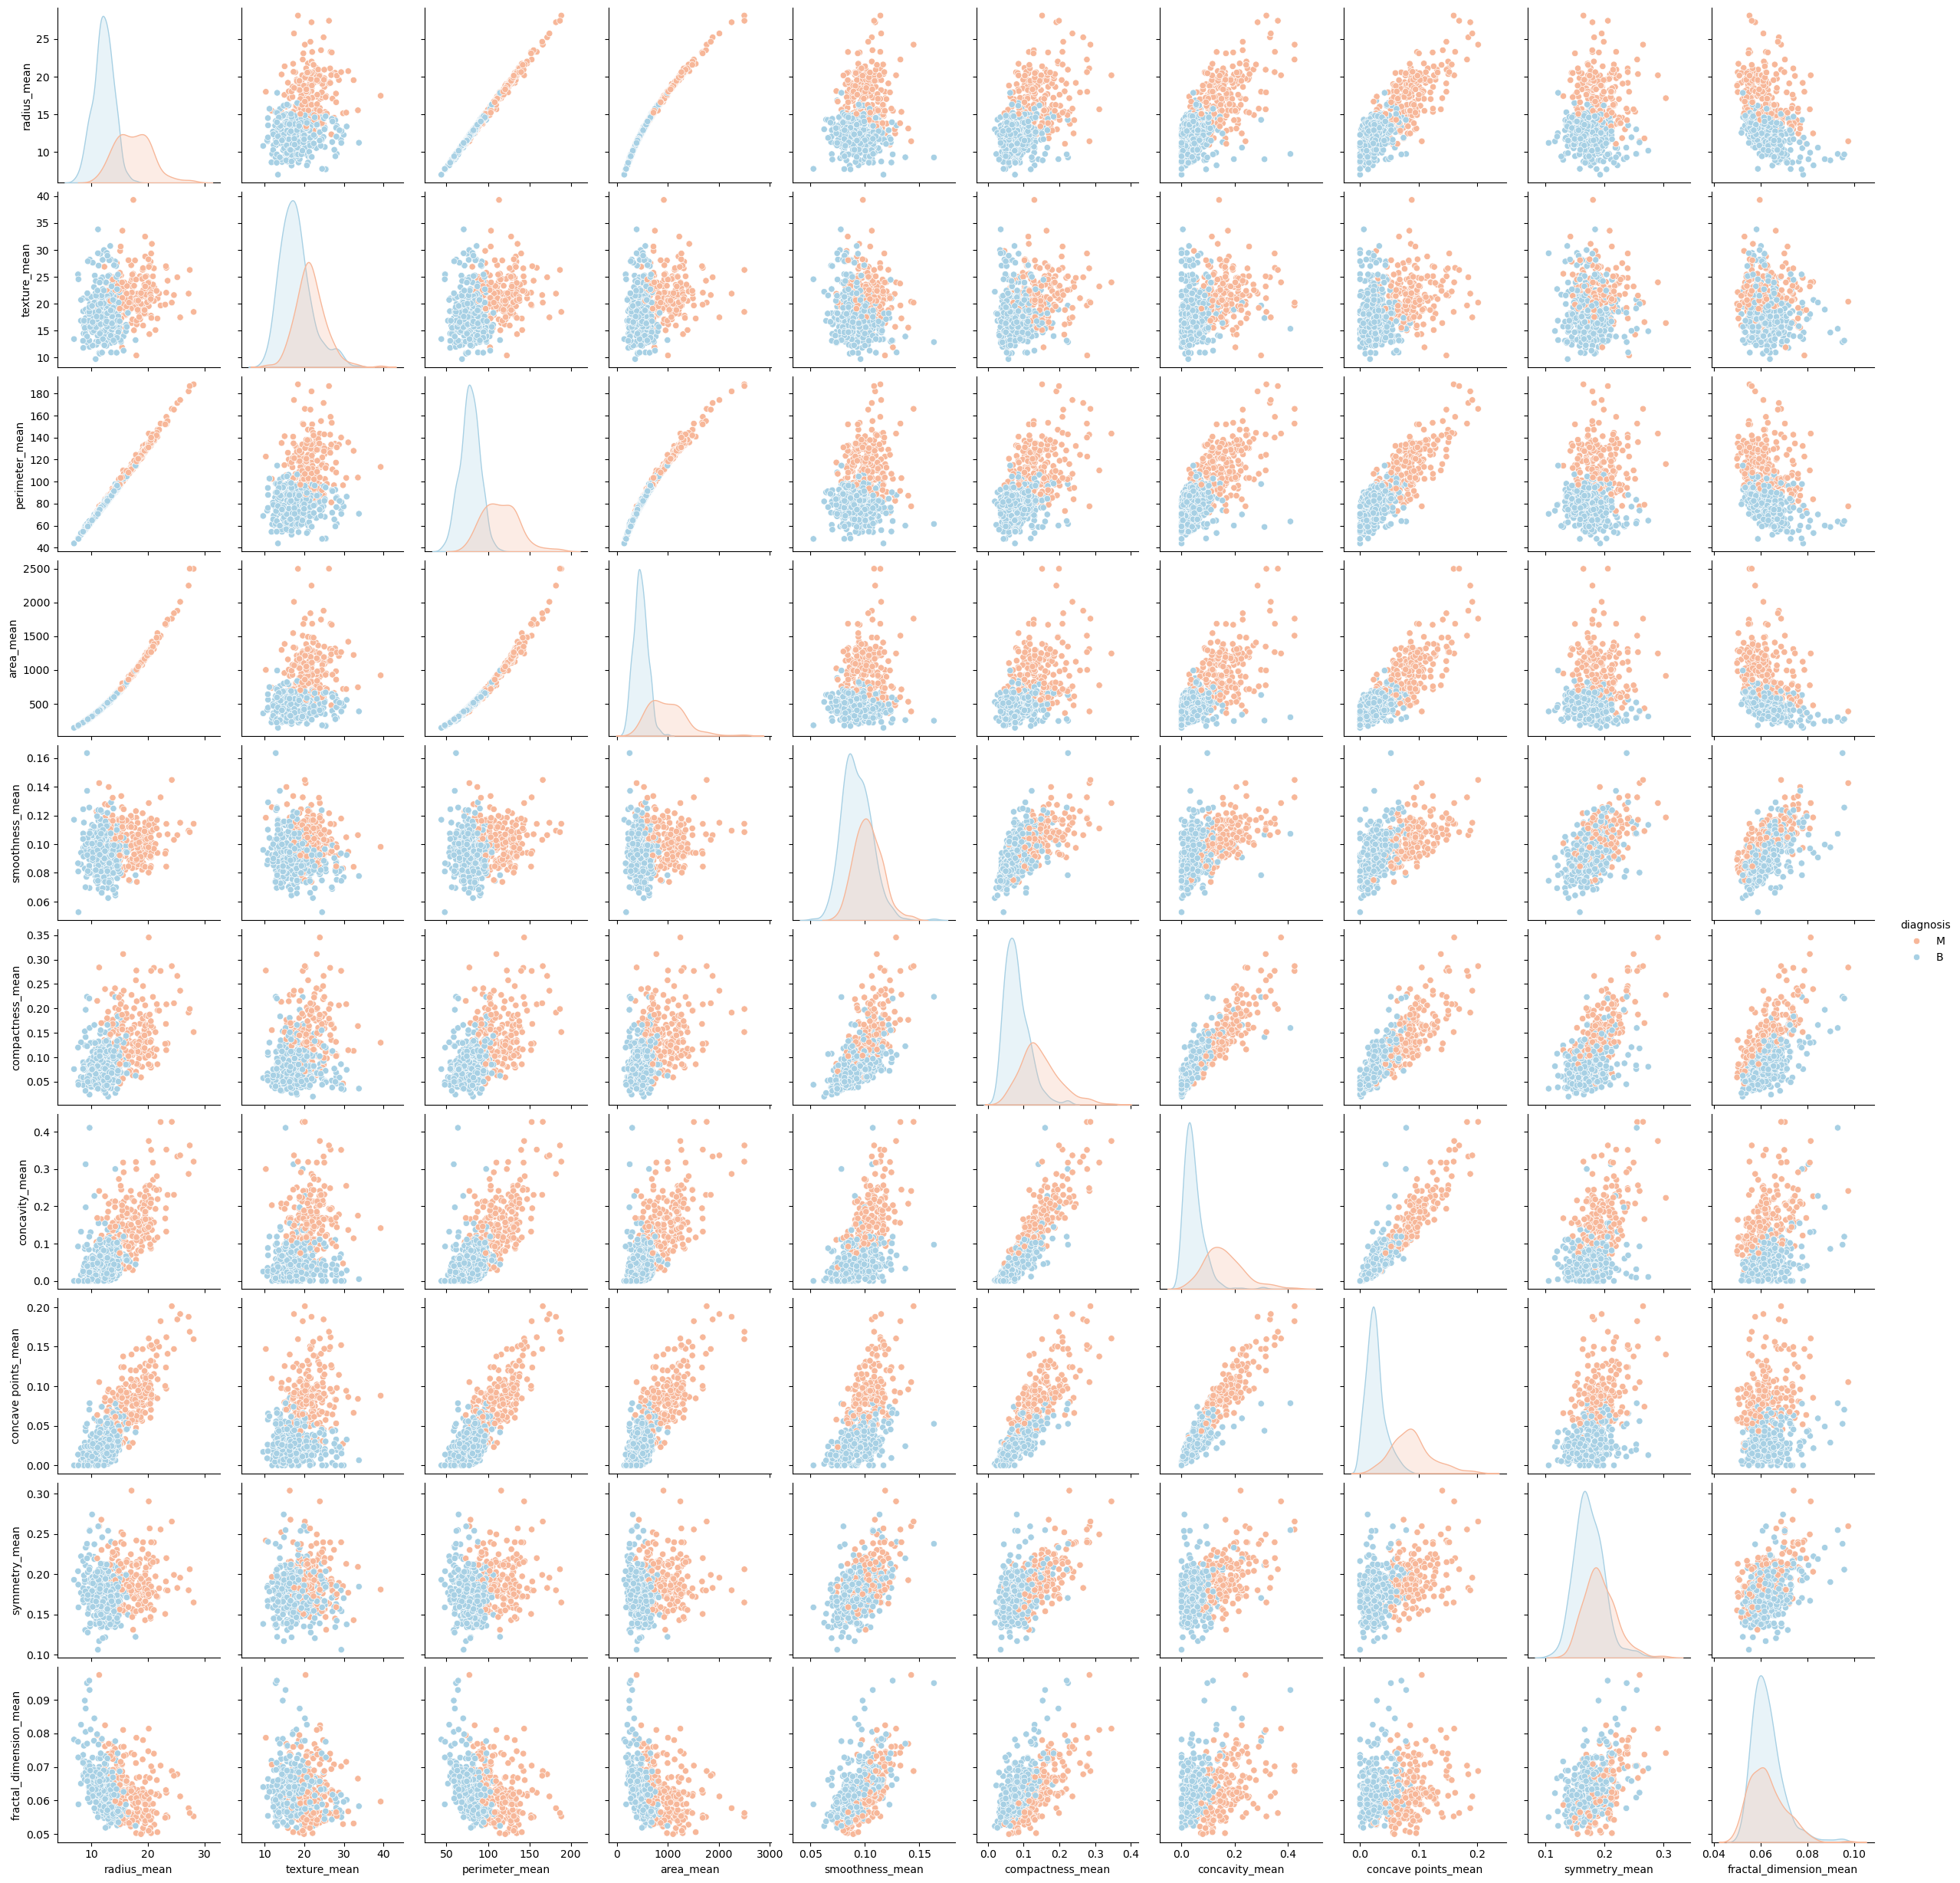

In [8]:
# generate a scatter plot matrix with the "mean" columns
cols = ['diagnosis',
        'radius_mean', 
        'texture_mean', 
        'perimeter_mean', 
        'area_mean', 
        'smoothness_mean', 
        'compactness_mean', 
        'concavity_mean',
        'concave points_mean', 
        'symmetry_mean', 
        'fractal_dimension_mean']

sns.pairplot(data=df[cols], hue='diagnosis', palette='RdBu')

#Feature Selection

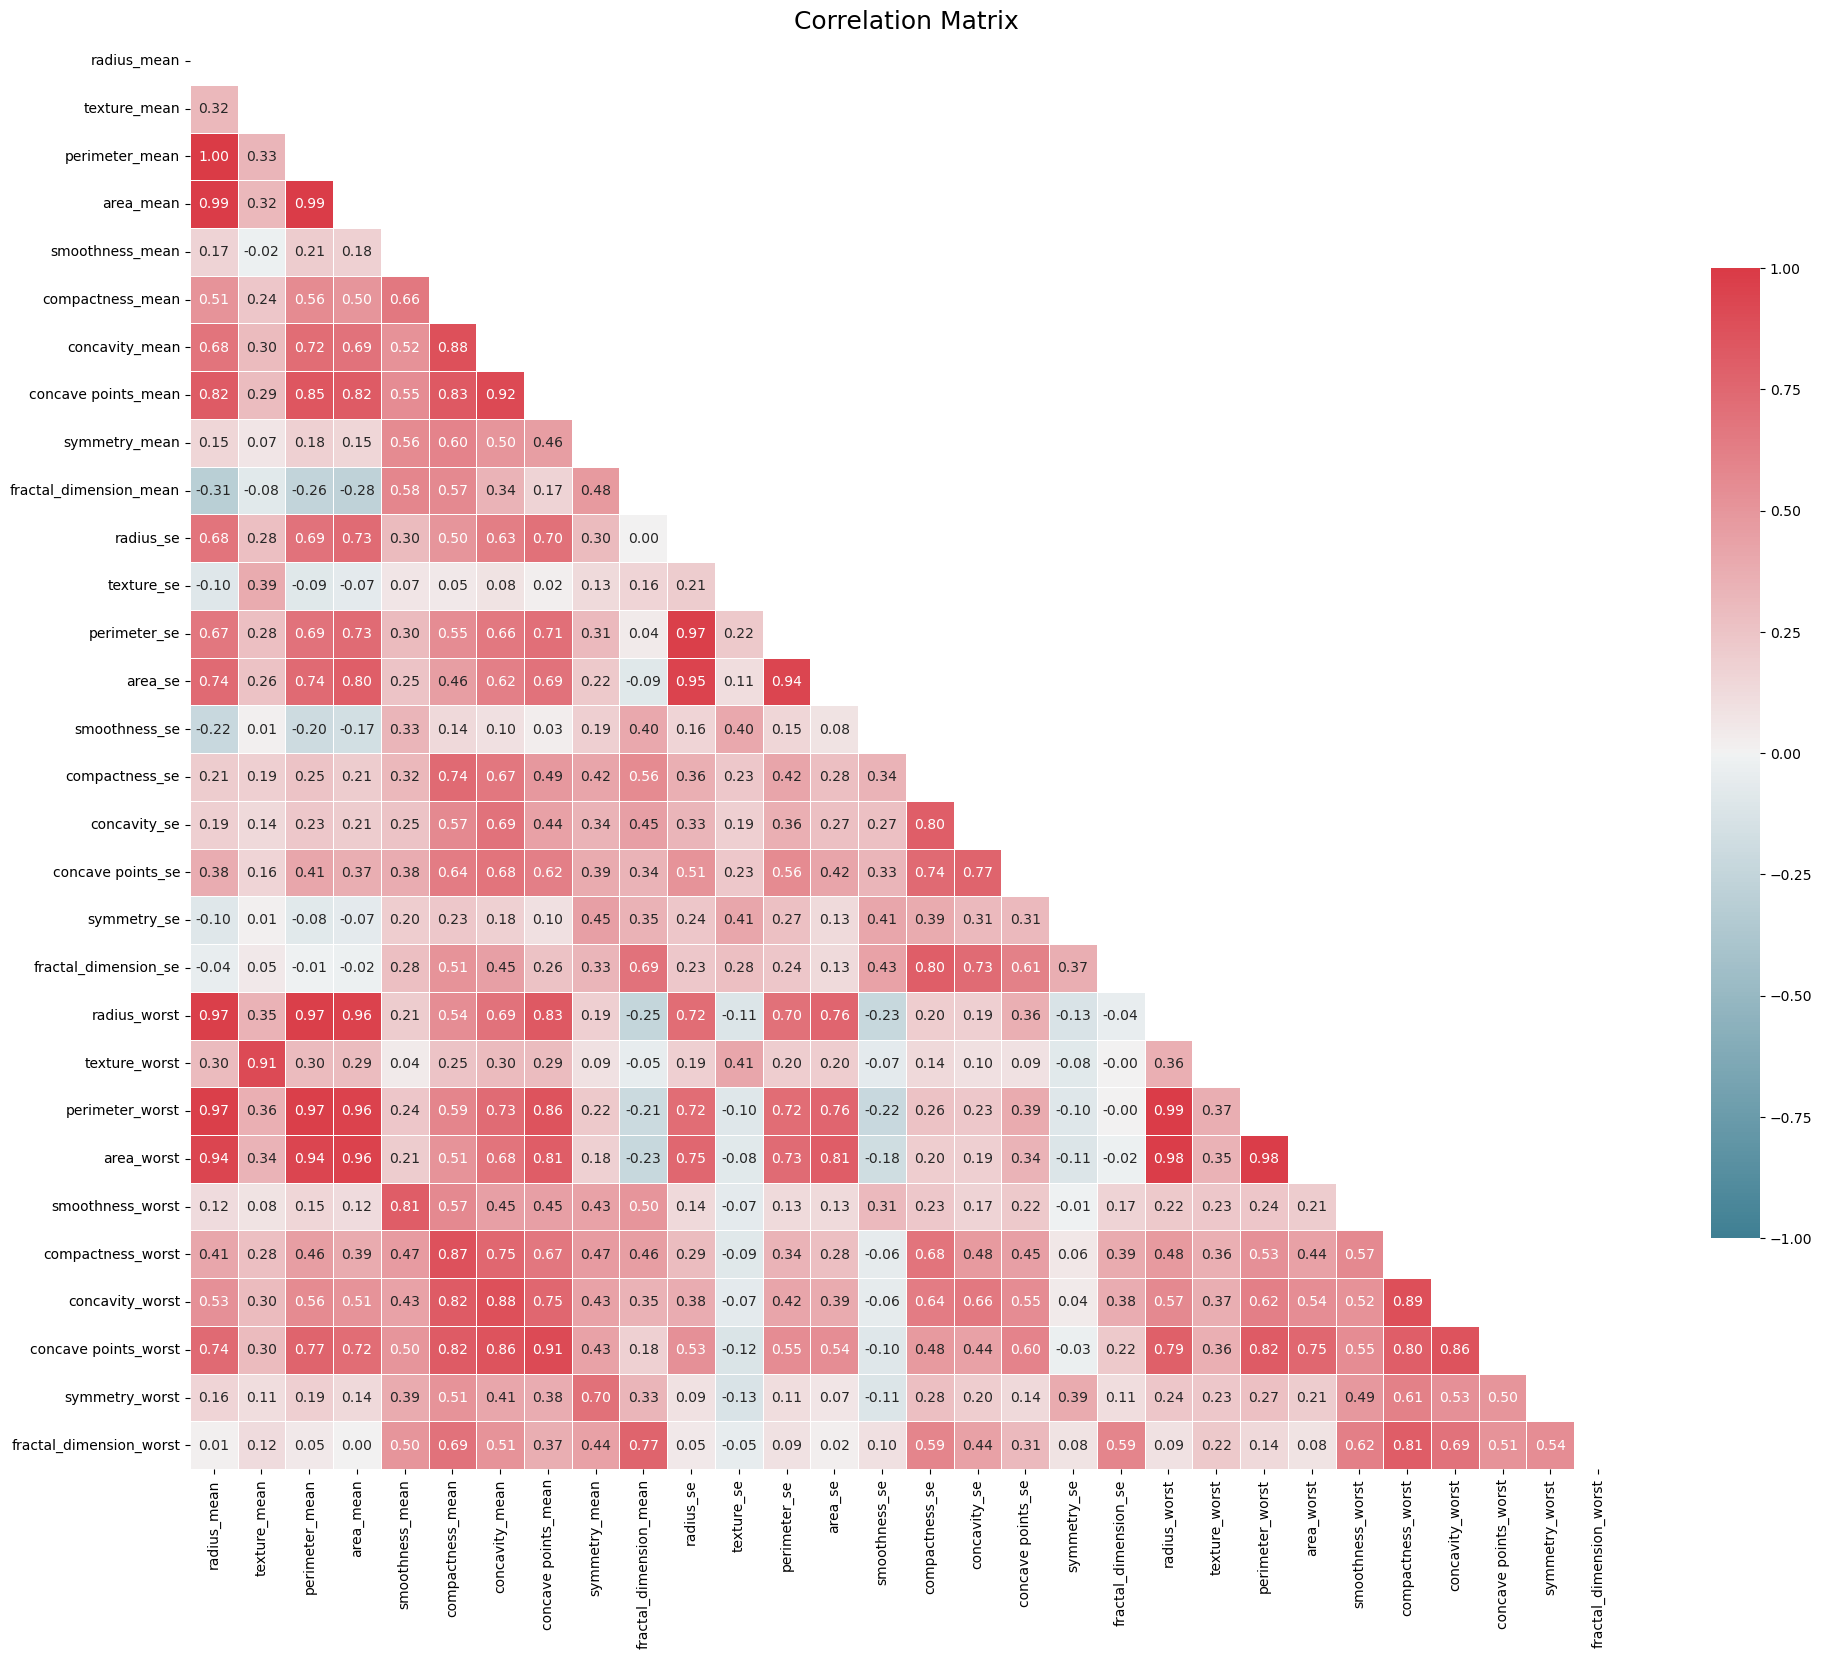

In [9]:
# Correlation matrix (numeric columns only)
corr = df.select_dtypes(include=np.number).corr().round(2)

# Mask for upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set figure size
plt.figure(figsize=(20, 20))

# Custom colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix", fontsize=18)
plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

#The Model - Logistic Regression

In [12]:
df['diagnosis'] = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

In [13]:
# Split the data into training and testing sets
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=40)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test)

In [17]:
#probability predictions (for ROC-AUC)
y_prob = model.predict_proba(X_test)[:,1]

In [18]:
print(f"Accuracy       : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.3f}")
print(f"Recall Score   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score       : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_prob):.3f}")

Accuracy       : 0.977
Precision Score: 0.964
Recall Score   : 0.964
F1 Score       : 0.964
ROC-AUC Score  : 0.992


In [19]:
print("Classification Report:\n",classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       115
           1       0.96      0.96      0.96        56

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171




Confusion Matrix:
[[113   2]
 [  2  54]]


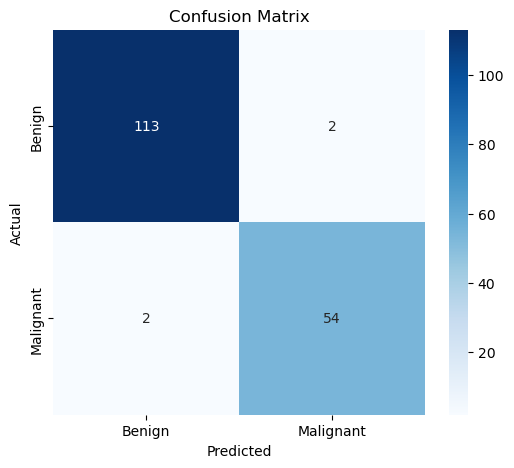

In [20]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

#viaualize confusion matrics
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

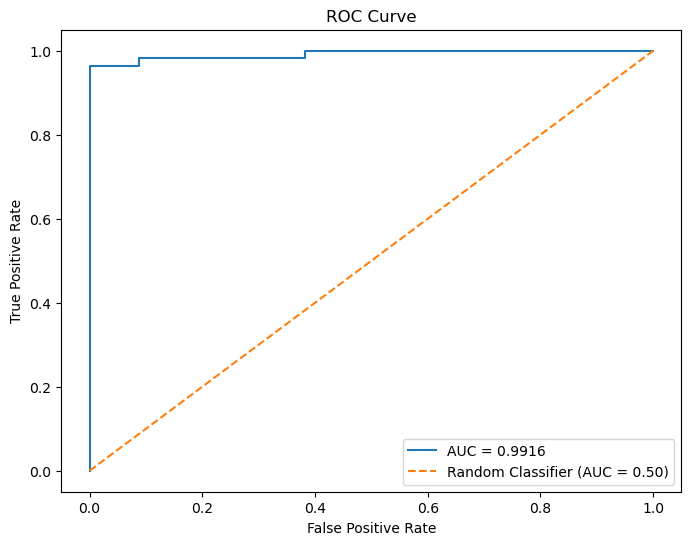

In [21]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Prediction Result Summary:
- Accuracy: 0.977 -> 97.7% predictions are correct.
- Precision: 0.964 -> 96.4% of predicted malignant tumors are actually malignant.
- Recall: 0.964 -> 96.4% of malignant tumors are detected.
- F1 Score: 0.964 -> 96.4% Strong balanced between precision and recall.
- ROC-AUC: 0.992 -> 99.2% Near-Perfect class separation.